Model 4：MIR + UAU + SIR（有迁移 + 有意识，但意识不触发迁移）

In [1]:
import numpy as np
import pandas as pd
import networkx as nx

# ============================================================================
# MIR 元种群模型（精确 MMCA 实现）
# 完全符合修正理论：感染风险基于来源地感染比例
# 移动网络：邻接矩阵决定可达性，移动概率 g 为标量
# 信息网络：独立 ER 随机图
# 状态：US, AS, AI, UR, AR
# ============================================================================

def generate_networks(N, avg_deg_info, avg_deg_mob, seed=42):
    """
    生成信息网络邻接矩阵 Wv 和移动网络邻接矩阵 Wmob，
    并根据移动网络构造移动概率矩阵 R。
    """
    np.random.seed(seed)
    
    # 信息网络：无向 ER 图
    p_info = avg_deg_info / (N-1) if N > 1 else 0
    G_info = nx.erdos_renyi_graph(N, p_info, seed=seed)
    Wv = nx.to_numpy_array(G_info, dtype=float)  # 0/1 对称矩阵
    
    # 移动网络：无向 ER 图
    p_mob = avg_deg_mob / (N-1) if N > 1 else 0
    G_mob = nx.erdos_renyi_graph(N, p_mob, seed=seed+1)
    Wmob = nx.to_numpy_array(G_mob, dtype=float)
    
    # 构建移动概率矩阵 R: 每行均分给邻居
    R = np.zeros((N, N))
    for i in range(N):
        neighbors = np.where(Wmob[i] > 0)[0]
        deg = len(neighbors)
        if deg > 0:
            R[i, neighbors] = 1.0 / deg
        else:
            R[i, i] = 1.0
    
    return Wv, Wmob, R

def compute_flows(n, g, R):
    N = len(n)
    flow = np.zeros((N, N))
    for j in range(N):
        stay = (1 - g) * n[j]
        move_out = g * n[j]
        for i in range(N):
            if i == j:
                flow[j, i] = stay + move_out * R[j, i]
            else:
                flow[j, i] = move_out * R[j, i]
    return flow

def compute_patch_infection_risk(flow, pI, beta_U, beta_A):
    N = flow.shape[0]
    N_U = np.zeros(N)
    N_A = np.zeros(N)
    for i in range(N):
        prod_U = 1.0
        prod_A = 1.0
        for j in range(N):
            f = flow[j, i]
            if f > 0:
                prod_U *= (1 - beta_U * pI[j]) ** f
                prod_A *= (1 - beta_A * pI[j]) ** f
        N_U[i] = 1 - prod_U
        N_A[i] = 1 - prod_A
    return N_U, N_A

def compute_individual_infection_risk(N_U, N_A, g, R):
    Q_U = (1 - g) * N_U + g * np.dot(R, N_U)
    Q_A = (1 - g) * N_A + g * np.dot(R, N_A)
    return Q_U, Q_A

def compute_info_risk(states, Wv, lambda1):
    N = states.shape[0]
    pA = states[:, 1] + states[:, 2] + states[:, 4]
    r = np.zeros(N)
    for i in range(N):
        prod = 1.0
        for j in range(N):
            if Wv[j, i] > 0:
                prod *= (1 - lambda1 * pA[j])
        r[i] = 1 - prod
    return r

def update_states(states, r, Q_U, Q_A, delta, mu):
    US, AS, AI, UR, AR = states.T
    new_US = US * (1 - r) * (1 - Q_U) + AS * delta * (1 - Q_U)
    new_AS = AS * (1 - delta) * (1 - Q_A) + US * r * (1 - Q_A)
    new_AI = (AI * (1 - mu)
              + AS * (1 - delta) * Q_A
              + AS * delta * Q_U
              + US * (1 - r) * Q_U
              + US * r * Q_A)
    new_UR = AI * delta * mu + AR * delta + UR * (1 - r)
    new_AR = AR * (1 - delta) + AI * (1 - delta) * mu + UR * r
    new_states = np.vstack([new_US, new_AS, new_AI, new_UR, new_AR]).T
    row_sum = new_states.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1
    new_states /= row_sum
    return new_states

def main_simulation(Time, N, params):
    lambda1 = params["lambda1"]
    delta   = params["delta"]
    mu      = params["mu"]
    beta_U  = params["beta_U"]
    beta_A  = params["beta_A"]
    g       = params["g"]
    avg_deg_info = params["avg_deg_info"]
    avg_deg_mob  = params["avg_deg_mob"]
    seed    = params.get("seed", 42)

    # 生成网络与移动矩阵
    Wv, Wmob, R = generate_networks(N, avg_deg_info, avg_deg_mob, seed)

    n = np.full(N, 200.0)
    states = np.zeros((N, 5))
    states[:, 0] = 0.99
    states[:, 2] = 0.01

    history = np.zeros((Time, 5))

    for t in range(Time):
        global_state = np.sum(states * n[:, None], axis=0) / np.sum(n)
        history[t] = global_state

        flow = compute_flows(n, g, R)
        pI = states[:, 2]
        N_U, N_A = compute_patch_infection_risk(flow, pI, beta_U, beta_A)
        Q_U, Q_A = compute_individual_infection_risk(N_U, N_A, g, R)
        r = compute_info_risk(states, Wv, lambda1)
        states = update_states(states, r, Q_U, Q_A, delta, mu)

    return history

# ============================================================================
# 重复实验主程序（200次，保存均值，无绘图）
# ============================================================================
if __name__ == "__main__":
    Time = 150
    N = 15
    num_simulations = 10   # 重复实验次数

    # 基础参数（不含种子）
    params_base = {
        "lambda1": 0.2,
        "delta": 0.15,
        "mu": 0.1,
        "beta_U": 0.003,
        "beta_A": 0.0015,
        "g": 0.2,
        "avg_deg_info": 2,
        "avg_deg_mob": 10,
    }

    # 累加所有仿真的历史
    total_history = np.zeros((Time, 5))

    for sim in range(num_simulations):
        # 每次实验使用不同的随机种子（保证网络与初始感染独立）
        params = params_base.copy()
        params["seed"] = 42 + sim   # 种子从42开始递增

        history = main_simulation(Time, N, params)
        total_history += history

        if (sim + 1) % 20 == 0:
            print(f"已完成 {sim + 1} / {num_simulations} 次仿真")

    # 计算均值
    mean_history = total_history / num_simulations

    # 保存均值CSV
    df = pd.DataFrame(mean_history, columns=["US", "AS", "AI", "UR", "AR"])
    df.to_csv("MIR_UAU_SIR_mean.csv", index=False)

    print(f"MIR 元种群模型 {num_simulations} 次重复实验完成，均值结果已保存。")
    print(df.head())

MIR 元种群模型 10 次重复实验完成，均值结果已保存。
         US        AS        AI        UR        AR
0  0.990000  0.000000  0.010000  0.000000  0.000000
1  0.979669  0.004413  0.014918  0.000150  0.000850
2  0.962204  0.013150  0.022154  0.000500  0.001992
3  0.933890  0.028748  0.032655  0.001122  0.003586
4  0.890083  0.054362  0.047582  0.002112  0.005860


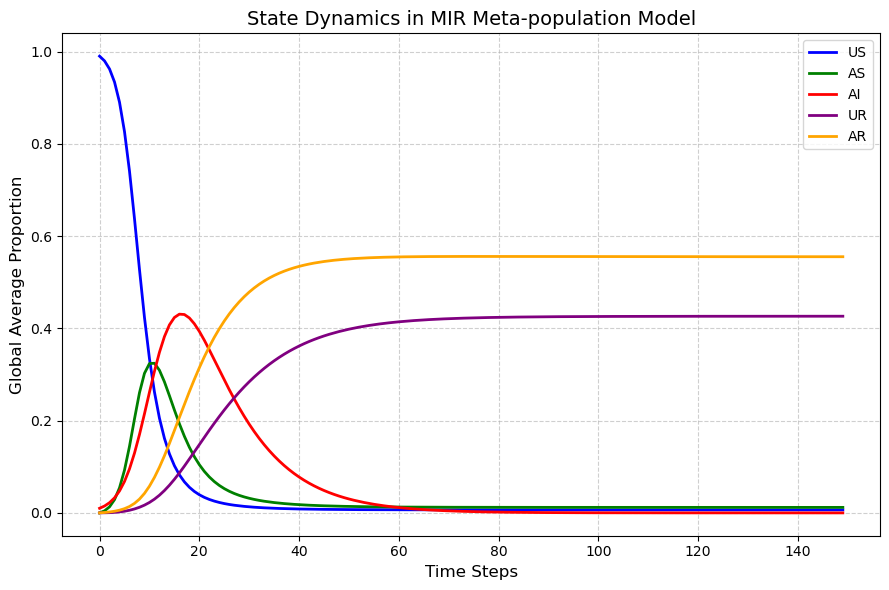

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# 1. 读取 MIR 基线模型的输出 CSV 文件
# ============================================
file_name = "MIR_UAU_SIR_mean.csv"  # 请根据实际文件名修改
df = pd.read_csv(file_name)

# ============================================
# 2. 设置颜色映射（与模板完全一致）
# ============================================
state_colors = {
    'US': 'blue',
    'AS': 'green',
    'AI': 'red',
    'UR': 'purple',
    'AR': 'orange'
}
state_labels = ['US', 'AS', 'AI', 'UR', 'AR']  # 顺序必须与 df 列顺序一致

# ============================================
# 3. 创建画布并绘制各状态曲线
# ============================================
plt.figure(figsize=(9, 6))

for i, label in enumerate(state_labels):
    plt.plot(
        df.index,                 # 时间步（行索引）
        df[label],               # 该状态全局比例
        label=label,
        color=state_colors[label],
        linewidth=2
    )

# ============================================
# 4. 图表装饰（模仿模板风格）
# ============================================
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Global Average Proportion', fontsize=12)
plt.title('State Dynamics in MIR Meta-population Model', fontsize=14)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 保存图片（可选）
# plt.savefig('MIR_UAU_SIR_single_run.png', dpi=300, bbox_inches='tight')
plt.show()